In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import sympy
from sympy.physics.vector import dynamicsymbols

# Variables

In [2]:
kappa, rho, g, i, u, mu, e_b, d_p, A_E, B_E, A, t, t_b, a, lambd, Z_LS, a = sympy.symbols(r"kappa varrho g i U mu epsilon_b d_p A_E B_E A t t_b alpha lambda Z_LS alpha")
u, e, Z_LS = dynamicsymbols("u epsilon Z_LS")
du = u.diff(t)
ddu = du.diff(t)
nu = mu / rho

constants = {
    rho: 1000,
    g: 9.81,
    i: 1/1000,
    mu: 1e-3,
    d_p: 1e-2,
    A_E: 180,
    B_E: 1.75,
    A: 26,
    e_b: 0.1,
    a: 5.,
    t_b: -2,
    lambd: 0.15,
    kappa: 0.41,
}
display(constants)

{varrho: 1000,
 g: 9.81,
 i: 0.001,
 mu: 0.001,
 d_p: 0.01,
 A_E: 180,
 B_E: 1.75,
 A: 26,
 epsilon_b: 0.1,
 alpha: 5.0,
 t_b: -2,
 lambda: 0.15,
 kappa: 0.41}

# Darcy

In [3]:
f = sympy.symbols("f")
K_KC = e**2 * d_p**2 / (A_E * (1-e)**2)
u_SSL = g*i*K_KC/nu
display(sympy.Equality(sympy.Symbol("u_{SSL}"), u_SSL))

F = B_E*(1-e) / d_p * rho *u**2
f_func = - mu*e*u/K_KC + F
display(sympy.Equality(f, f_func))

Eq(u_{SSL}, d_p**2*g*i*varrho*epsilon(t)**2/(A_E*mu*(1 - epsilon(t))**2))

Eq(f, -A_E*mu*(1 - epsilon(t))**2*u(t)/(d_p**2*epsilon(t)) + B_E*varrho*(1 - epsilon(t))*u(t)**2/d_p)

# Stresses

In [4]:
tau_v = dynamicsymbols("tau_v")
tau_v_func = mu * (e.diff(t)*u + e*du)
display(sympy.Equality(tau_v, tau_v_func))
display(sympy.Equality(tau_v.diff(t), tau_v_func.diff(t)))

Eq(tau_v(t), mu*(epsilon(t)*Derivative(u(t), t) + u(t)*Derivative(epsilon(t), t)))

Eq(Derivative(tau_v(t), t), mu*(epsilon(t)*Derivative(u(t), (t, 2)) + u(t)*Derivative(epsilon(t), (t, 2)) + 2*Derivative(epsilon(t), t)*Derivative(u(t), t)))

In [5]:
l_t = sympy.symbols("ell_t")
tau_t = dynamicsymbols("tau_t")
l_t_func = kappa*Z_LS*(1-sympy.exp(-sympy.sqrt(Z_LS*u/nu)/A))
display(sympy.Equality(l_t, l_t_func))

tau_t_func = rho*e*l_t_func**2*du
display(sympy.Equality(tau_t, tau_t_func))
display(sympy.Equality(dynamicsymbols("tau_t").diff(t), tau_t_func.diff(t)))

Eq(ell_t, kappa*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))*Z_LS(t))

Eq(tau_t(t), kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), t))

Eq(Derivative(tau_t(t), t), kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), (t, 2)) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t) + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)*epsilon(t)*Derivative(Z_LS(t), t)*Derivative(u(t), t) + 2*kappa**2*mu*sqrt(varrho*Z_LS(t)*u(t)/mu)*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))*(varrho*Z_LS(t)*Derivative(u(t), t)/(2*mu) + varrho*u(t)*Derivative(Z_LS(t), t)/(2*mu))*Z_LS(t)*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A)*Derivative(u(t), t)/(A*u(t)))

In [6]:
ell_d = sympy.symbols("ell_d tau_d")
tau_d = dynamicsymbols("tau_d")
ell_d_func = rho*e*d_p**2*lambd*(1-e)/(1-e_b)*u/d_p * du
display(sympy.Equality(ell_d, ell_d_func))

tau_d_func = rho*e*ell_d_func**2*u/d_p*du
display(sympy.Equality(tau_d, tau_d_func))
display(sympy.Equality(tau_d.diff(t), tau_d_func.diff(t)))

False

Eq(tau_d(t), d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**3/(1 - epsilon_b)**2)

Eq(Derivative(tau_d(t), t), 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2*Derivative(u(t), (t, 2))/(1 - epsilon_b)**2 + 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**2*Derivative(u(t), t)**4/(1 - epsilon_b)**2 + 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**2*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2 - 2*d_p*lambda**2*varrho**3*(1 - epsilon(t))*epsilon(t)**3*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2)

In [7]:
sympy.Equality(0, (
    e*rho*g*i + (tau_d+tau_t+tau_v).diff(t) + e*f - rho*mu*e.diff(t)*du
))

Eq(0, f*epsilon(t) + g*i*varrho*epsilon(t) - mu*varrho*Derivative(epsilon(t), t)*Derivative(u(t), t) + Derivative(tau_d(t), t) + Derivative(tau_t(t), t) + Derivative(tau_v(t), t))

## Summing up

$$\tau_v' \rightarrow u'' + u'^2 + u'$$
$$\tau_t' \rightarrow \left(1-e^{-\sqrt{u}}\right)\left(u'' + u' + u'^2\right)$$
$$\tau_d' \rightarrow u'^2 u'' + u'^2 + u' + u'^4 + u'^3$$

# Injecting expressions

In [8]:
funcs = {k: globals()[f"{k}_func"] for k in globals() if f"{k}_func" in globals()}
display(funcs)

{'f': -A_E*mu*(1 - epsilon(t))**2*u(t)/(d_p**2*epsilon(t)) + B_E*varrho*(1 - epsilon(t))*u(t)**2/d_p,
 'tau_v': mu*(epsilon(t)*Derivative(u(t), t) + u(t)*Derivative(epsilon(t), t)),
 'l_t': kappa*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))*Z_LS(t),
 'tau_t': kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), t),
 'ell_d': d_p*lambda*varrho*(1 - epsilon(t))*epsilon(t)*u(t)*Derivative(u(t), t)/(1 - epsilon_b),
 'tau_d': d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**3/(1 - epsilon_b)**2}

## Writing full equation

In [9]:
expr = (
    e*rho*g*i + ((tau_v_func + tau_t_func + tau_d_func).subs(funcs)).diff(t) + e*f - rho*mu*e.subs(funcs).diff(t)*du.subs(funcs)
).subs(funcs).subs(funcs).subs(funcs)
display(expr)

txt = "# steady-state uniform flow (double-average)"
txt += "\n"
txt += "$$"
txt += sympy.latex(expr)
txt += "$$"
Path("_ed.md").write_text(txt)

3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2*Derivative(u(t), (t, 2))/(1 - epsilon_b)**2 + 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**2*Derivative(u(t), t)**4/(1 - epsilon_b)**2 + 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**2*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2 - 2*d_p*lambda**2*varrho**3*(1 - epsilon(t))*epsilon(t)**3*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2 + g*i*varrho*epsilon(t) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*epsilon(t)*Derivative(u(t), (t, 2)) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t) + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)*epsilon(t)*Derivative(Z_LS(t), t)*Derivative(u(t), t) - mu*varrho*Derivative(epsilon(t), t)*Derivative(u(t), t) + mu*(epsilon(t)*Derivative(u(t), (t, 

2951

# Comparing with Lamb

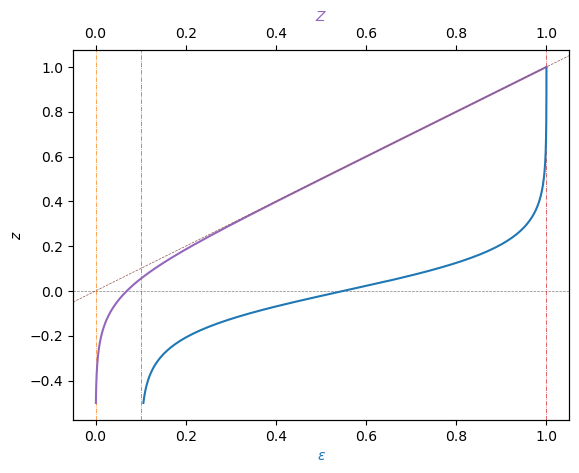

In [ ]:
Z_LS_numerical = 1/2*(t + sympy.ln(sympy.cosh(a*t))/a)
Z_LS_numerical = Z_LS_numerical - Z_LS_numerical.subs(dict(t=t_b))
e_numerical = (1-e_b)*Z_LS_numerical.diff(t) + e_b

z_arr = np.linspace(-0.5, 1, num=200)
fig, ax1 = plt.subplots(sharey=True)
ax2 = ax1.twiny()
ax2.grid(False)

ax1.axline((0, 0), slope=0, ls="--", c="gray", lw=0.5)
axlinestyle = dict(slope=np.inf, ls="-.", lw=0.5)
ax1.axline((0, 0), **axlinestyle, c="C1")
ax1.axline((constants[e_b], 0), **axlinestyle, c="C2")
ax1.axline((1, 0), **axlinestyle, c="C3")

ax1.plot(sympy.lambdify(t, e_numerical.subs(constants))(z_arr), z_arr, c="C0")
ax2.plot(sympy.lambdify(t, Z_LS_numerical.subs(constants))(z_arr), z_arr, c="C4")
ax2.axline((0, 0), slope=1, ls="--", c="C5", lw=0.5)

ax1.set_xlabel(r"$\epsilon$", color="C0")
ax1.set_ylabel("$z$")
ax2.set_xlabel("$Z$", color="C4")
plt.show()

z_arr.min() = np.float64(0.0) 0.03


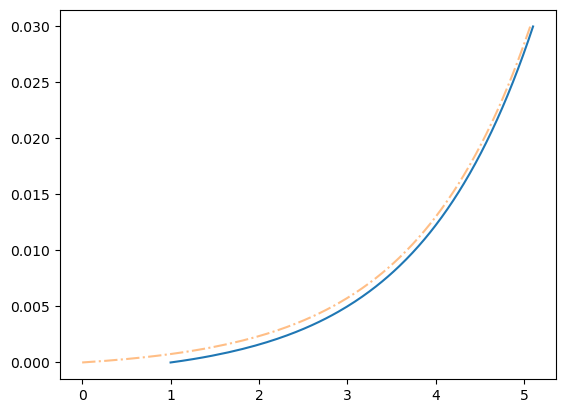

mu*(epsilon(t)*Derivative(u(t), t) + u(t)*Derivative(epsilon(t), t))

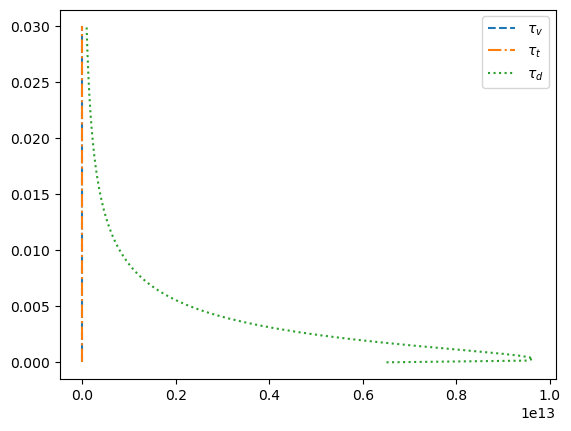

In [ ]:
z_arr = np.linspace(0, 3*constants[d_p], num=200)
print(f"{z_arr.min() = } {z_arr.max()}")

def lamb_profile(z, u0, h, i=constants[i], kappa=constants[kappa], ks=2*constants[d_p], rho=constants[rho], g=constants[g]):
    u_shear = (rho*g*h*i)**0.5
    return u0 + u_shear/kappa * np.log(1 + 30*z/ks * np.exp(-kappa*u0/u_shear))

u_lamb = lamb_profile(z_arr, 1, z_arr.max())
du_lamb = np.pad(np.diff(u_lamb) / np.diff(z_arr), (1, 0),mode="edge")

plt.plot(u_lamb, z_arr)
plt.plot(lamb_profile(z_arr, 0, z_arr.max()), z_arr, ls="-.", alpha=0.5)
plt.show()

display(tau_v_func)
tau_v_lamb = sympy.lambdify([t, du, u], tau_v_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)
tau_t_lamb = sympy.lambdify([t, du, u], tau_t_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)
tau_d_lamb = sympy.lambdify([t, du, u], tau_d_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)

plt.plot(tau_v_lamb, z_arr, label=r"$\tau_v$", ls="--")
plt.plot(tau_t_lamb, z_arr, label=r"$\tau_t$", ls="-.")
plt.plot(tau_d_lamb, z_arr, label=r"$\tau_d$", ls=":")
plt.legend()
plt.show()

# Isolating the second derivative

In [10]:
ddu_term = ((expr - expr.subs({ddu: 0}))).expand()
ddu_factor = (ddu_term / ddu).expand()#.simplify()
display(ddu_term)
display(ddu_factor)

3*d_p*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2*Derivative(u(t), (t, 2))/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2*Derivative(u(t), (t, 2))/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2*Derivative(u(t), (t, 2))/(epsilon_b**2 - 2*epsilon_b + 1) + kappa**2*varrho*Z_LS(t)**2*epsilon(t)*Derivative(u(t), (t, 2)) - 2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A)*Derivative(u(t), (t, 2)) + kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-2*sqrt(varrho*Z_LS(t)*u(t)/mu)/A)*Derivative(u(t), (t, 2)) + mu*epsilon(t)*Derivative(u(t), (t, 2))

3*d_p*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + kappa**2*varrho*Z_LS(t)**2*epsilon(t) - 2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-2*sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + mu*epsilon(t)

In [11]:
expr.subs({ddu: 0}).expand()

-A_E*mu*epsilon(t)**2*u(t)/d_p**2 + 2*A_E*mu*epsilon(t)*u(t)/d_p**2 - A_E*mu*u(t)/d_p**2 - B_E*varrho*epsilon(t)**2*u(t)**2/d_p + B_E*varrho*epsilon(t)*u(t)**2/d_p + 3*d_p*lambda**2*varrho**3*epsilon(t)**5*u(t)**2*Derivative(u(t), t)**4/(epsilon_b**2 - 2*epsilon_b + 1) + 5*d_p*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p*lambda**2*varrho**3*epsilon(t)**4*u(t)**2*Derivative(u(t), t)**4/(epsilon_b**2 - 2*epsilon_b + 1) - 8*d_p*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p*lambda**2*varrho**3*epsilon(t)**3*u(t)**2*Derivative(u(t), t)**4/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p*lambda**2*varrho**3*epsilon(t)**2*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(epsilon_b**2 - 2*epsilon_b + 1) + g*i*varrho*epsilon(t) + kappa**2*varrho*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t) - 2*kappa**2*varrho*Z_L

In [12]:
# display(ddu_factor.expand()*u.diff(t, 2) + expr.subs({u.diff(t, 2): 0}).expand())
# print("---")
# display(expr.expand())
# print("===>")
display(((ddu_factor.expand()*ddu + expr.subs({ddu: 0})) - expr).expand())

0

In [13]:
ddu_expr = (- expr.subs({ddu: 0}) / ddu_factor).expand()
display(ddu_expr)
assert "Derivative(u(t), (t, 2))" in str(expr)
assert "Derivative(u(t), (t, 2))" not in str(ddu_expr)

A_E*mu*epsilon(t)**2*u(t)/(3*d_p**3*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p**3*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p**3*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t) - 2*d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-2*sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + d_p**2*mu*epsilon(t)) - 2*A_E*mu*epsilon(t)*u(t)/(3*d_p**3*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p**3*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p**3*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t) - 2*d

In [14]:
sympy.collect(expr.subs({ddu: sympy.Symbol("u''")}), sympy.Symbol("u''"))

3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**2*Derivative(u(t), t)**4/(1 - epsilon_b)**2 + 3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**2*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2 - 2*d_p*lambda**2*varrho**3*(1 - epsilon(t))*epsilon(t)**3*u(t)**3*Derivative(epsilon(t), t)*Derivative(u(t), t)**3/(1 - epsilon_b)**2 + g*i*varrho*epsilon(t) + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)**2*Derivative(epsilon(t), t)*Derivative(u(t), t) + 2*kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A))**2*Z_LS(t)*epsilon(t)*Derivative(Z_LS(t), t)*Derivative(u(t), t) - mu*varrho*Derivative(epsilon(t), t)*Derivative(u(t), t) + mu*(u''*epsilon(t) + u(t)*Derivative(epsilon(t), (t, 2)) + 2*Derivative(epsilon(t), t)*Derivative(u(t), t)) + u''*(3*d_p*lambda**2*varrho**3*(1 - epsilon(t))**2*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(1 - epsilon_b)**2 + kappa**2*varrho*(1 - exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A)

In [15]:
display(
    + (ddu_expr - ddu)  # .simplify()
    - expr  # .simplify()
)

A_E*mu*epsilon(t)**2*u(t)/(3*d_p**3*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p**3*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p**3*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t) - 2*d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t)*exp(-2*sqrt(varrho*Z_LS(t)*u(t)/mu)/A) + d_p**2*mu*epsilon(t)) - 2*A_E*mu*epsilon(t)*u(t)/(3*d_p**3*lambda**2*varrho**3*epsilon(t)**5*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) - 6*d_p**3*lambda**2*varrho**3*epsilon(t)**4*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + 3*d_p**3*lambda**2*varrho**3*epsilon(t)**3*u(t)**3*Derivative(u(t), t)**2/(epsilon_b**2 - 2*epsilon_b + 1) + d_p**2*kappa**2*varrho*Z_LS(t)**2*epsilon(t) - 2*d

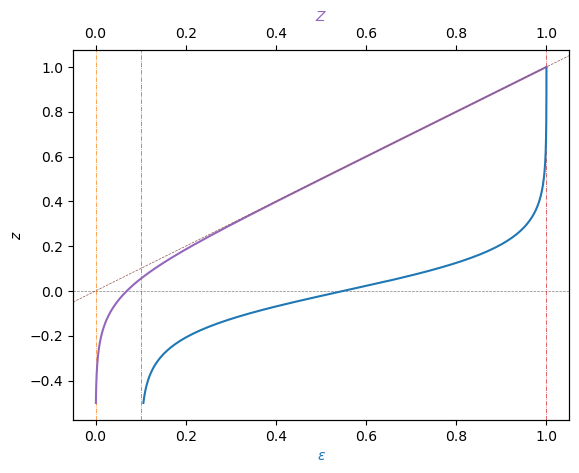

In [16]:
Z_LS_numerical = 1/2*(t + sympy.ln(sympy.cosh(a*t))/a)
Z_LS_numerical = Z_LS_numerical - Z_LS_numerical.subs(dict(t=t_b))
e_numerical = (1-e_b)*Z_LS_numerical.diff(t) + e_b

z_arr = np.linspace(-0.5, 1, num=200)
fig, ax1 = plt.subplots(sharey=True)
ax2 = ax1.twiny()
ax2.grid(False)

ax1.axline((0, 0), slope=0, ls="--", c="gray", lw=0.5)
axlinestyle = dict(slope=np.inf, ls="-.", lw=0.5)
ax1.axline((0, 0), **axlinestyle, c="C1")
ax1.axline((constants[e_b], 0), **axlinestyle, c="C2")
ax1.axline((1, 0), **axlinestyle, c="C3")

ax1.plot(sympy.lambdify(t, e_numerical.subs(constants))(z_arr), z_arr, c="C0")
ax2.plot(sympy.lambdify(t, Z_LS_numerical.subs(constants))(z_arr), z_arr, c="C4")
ax2.axline((0, 0), slope=1, ls="--", c="C5", lw=0.5)

ax1.set_xlabel(r"$\epsilon$", color="C0")
ax1.set_ylabel("$z$")
ax2.set_xlabel("$Z$", color="C4")
plt.show()

In [17]:
ddu_computer = ddu_expr.subs({Z_LS: Z_LS_numerical, e: e_numerical, e.diff(t): e_numerical.diff(t)} | constants).expand().doit()# .simplify()
# display(ddu_computer)
ddu_computer = sympy.lambdify([t, du, u], ddu_computer)
# display(ddu_computer)
display(ddu_computer(1, 1, 1e-5))

np.float64(-94006.67742512244)

z_arr.min() = np.float64(0.0) 0.03


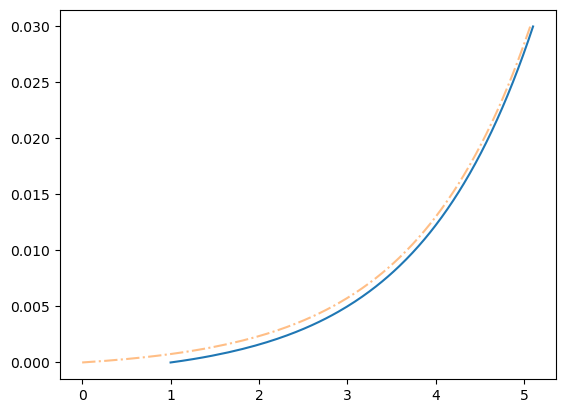

mu*(epsilon(t)*Derivative(u(t), t) + u(t)*Derivative(epsilon(t), t))

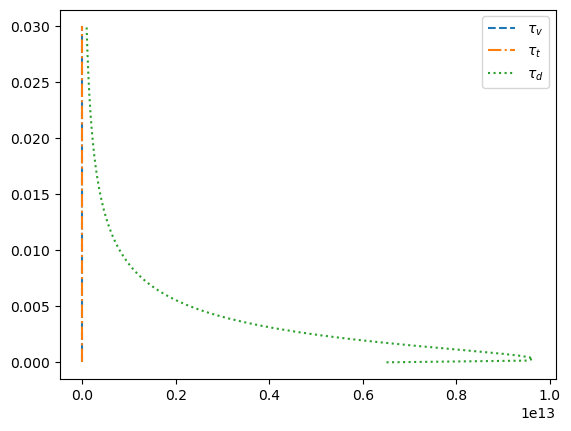

In [20]:
z_arr = np.linspace(0, 3*constants[d_p], num=200)
print(f"{z_arr.min() = } {z_arr.max()}")

def lamb_profile(z, u0, h, i=constants[i], kappa=constants[kappa], ks=2*constants[d_p], rho=constants[rho], g=constants[g]):
    u_shear = (rho*g*h*i)**0.5
    return u0 + u_shear/kappa * np.log(1 + 30*z/ks * np.exp(-kappa*u0/u_shear))

u_lamb = lamb_profile(z_arr, 1, z_arr.max())
du_lamb = np.pad(np.diff(u_lamb) / np.diff(z_arr), (1, 0),mode="edge")

plt.plot(u_lamb, z_arr)
plt.plot(lamb_profile(z_arr, 0, z_arr.max()), z_arr, ls="-.", alpha=0.5)
plt.show()

display(tau_v_func)
tau_v_lamb = sympy.lambdify([t, du, u], tau_v_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)
tau_t_lamb = sympy.lambdify([t, du, u], tau_t_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)
tau_d_lamb = sympy.lambdify([t, du, u], tau_d_func.subs({Z_LS: Z_LS_numerical, e: e_numerical} | constants).doit())(z_arr, du_lamb, u_lamb)

plt.plot(tau_v_lamb, z_arr, label=r"$\tau_v$", ls="--")
plt.plot(tau_t_lamb, z_arr, label=r"$\tau_t$", ls="-.")
plt.plot(tau_d_lamb, z_arr, label=r"$\tau_d$", ls=":")
plt.legend()
plt.show()

In [19]:
u_finite = np.zeros(z_arr.shape, dtype=np.float64)
ub = e_b*rho*g*i * mu*e*d_p**2/(A_E*(1-e)**2)
display(ub)
ub_val = ub.subs({e: e_numerical} | constants | {t: z_arr.min()})  # TODO Ergun
u_finite[:2] = ub_val
du = du

for i, (tp, ti) in enumerate(zip(z_arr[:-2], z_arr[1:-1]), start=1):
    print(f"{i:>2} | {u_finite[i] = :+.3e} | ", end="")
    dz = (ti - tp)
    du_val = (u_finite[i] - u_finite[i-1]) / dz
    ddu_val = ddu_computer(ti, du_val, u_finite[i])
    ddu_val = sympy.re(ddu_val)
    print(f"{ddu_val = :+.1e} {du_val = :+.1e} {dz = :+.1e} | ", end="")
    du_val = du_val + ddu_val*dz
    u_finite[i+1] = u_finite[i] + du_val*dz
    print(f"{u_finite[i+1] = :+.3e}")

plt.plot(u_finite, z_arr, '-o')
plt.show()

d_p**2*epsilon_b*g*i*mu*varrho*epsilon(t)/(A_E*(1 - epsilon(t))**2)

 1 | u_finite[i] = +1.480e-09 | ddu_val = -9.8e+3 du_val = +0.0e+00 dz = +1.5e-04 | u_finite[i+1] = -2.229e-04
 2 | u_finite[i] = -2.229e-04 | 

<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in sqrt
  return -20759.4140625*_Dummy_34**4*_Dummy_35**2*sinh(5.0*t)**4/(12455.6484375*_Dummy_34**2*_Dummy_35**3*sinh(5.0*t)**5/cosh(5.0*t) + 20759.4140625*_Dummy_34**2*_Dummy_35**3*sinh(5.0*t)**4 - 23066.0156250001*_Dummy_34**2*_Dummy_35**3*sinh(5.0*t)**3*cosh(5.0*t) - 43227.4218750001*_Dummy_34**2*_Dummy_35**3*sinh(5.0*t)**2*cosh(5.0*t)**2 + 10336.9921874999*_Dummy_34**2*_Dummy_35**3*sinh(5.0*t)*cosh(5.0*t)**3 + 22741.3828125*_Dummy_34**2*_Dummy_35**3*cosh(5.0*t)**4 + 15.3181125*t**2*sinh(5.0*t)*cosh(5.0*t)**3 + 18.7221375*t**2*cosh(5.0*t)**4 + 15.3181125*t**2*exp(-24.325212770526*sqrt(10)*sqrt(0.5*_Dummy_35*t + 0.1*_Dummy_35*log(cosh(5.0*t)) + 0.0693147178498792*_Dummy_35))*sinh(5.0*t)*cosh(5.0*t)**3 + 18.7221375*t**2*exp(-24.325212770526*sqrt(10)*sqrt(0.5*_Dummy_35*t + 0.1*_Dummy_35*log(cosh(5.0*t)) + 0.0693147178498792*_Dummy_35))*cosh(5.0*t)**4 - 30.636225*t**2*exp(-12.162606385263*sqrt(10)*sqrt(0.5*_Dummy_35*t +

TypeError: unsupported format string passed to NaN.__format__